# Capítulo 5 - Estatística

Página 91-107

## 5.0 Resumo

**Descrevendo um conjunto de dados**
- Medidas de tendência central: média, mediana, moda
- Medidas de dispersão: amplitude (range), variância, desvio padrão
- Quantis/percentis (valores que dividem os dados em partes)

**Correlação**
- Covariância — mede se duas variáveis tendem a variar juntas na mesma direção
- Correlação — versão normalizada da covariância (entre -1 e 1), mais interpretável
- Centralização de dados (subtrair a média de cada elemento, resultando em nova média zero) — conceito que veio à tona quando discutimos como `dot(x,y)` é usado no cálculo da covariância

**Correlação e causalidade**
- Correlação não implica causalidade
- Variável mediadora (está no meio do caminho causal, X→M→Y) vs. variável de confusão/confundidora (causa comum externa a X e Y)
- A necessidade de experimentos controlados para estabelecer causalidade de fato

## 5.1 Descrevendo um conjunto de dados

In [ ]:
# relatorio de quantos amigos os membros possuem

# Initialize the generator
import numpy as np
rng = np.random.default_rng()

# simula a quantidade de amigos cada
num_friends = (
    rng.integers(low=0, high=11, size=200).tolist()
    + rng.integers(low=11, high=20, size=40).tolist()
    + rng.integers(low=22, high=101, size=5).tolist()
    + [100]
)
print("qtd usuarios:", len(num_friends))
print("amostra quantidade de usuarios:", num_friends[:10], num_friends[-10:])

qtd usuarios: 246
amostra quantidade de usuarios: [5, 8, 1, 1, 0, 1, 1, 5, 8, 0] [19, 19, 14, 12, 27, 34, 48, 75, 88, 100]


In [ ]:
# conta a frequencia de ocorrencias da quantidade de amigos que um usuario tem
from typing import Counter
friend_counts = Counter(num_friends)
friend_counts

Counter({5: 18,
         8: 18,
         1: 26,
         0: 17,
         9: 11,
         2: 22,
         10: 16,
         6: 26,
         7: 22,
         3: 12,
         4: 12,
         13: 3,
         14: 7,
         16: 4,
         11: 5,
         15: 3,
         18: 2,
         17: 2,
         12: 7,
         19: 7,
         27: 1,
         34: 1,
         48: 1,
         75: 1,
         88: 1,
         100: 1})

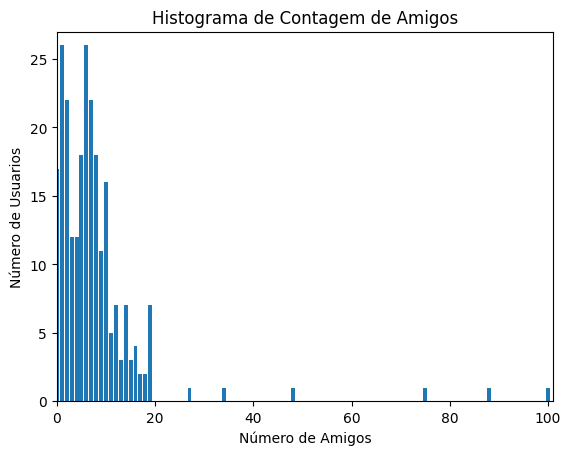

In [ ]:
import matplotlib.pyplot as plt

# range com maior quantidade de amigos que um usuario tem
xs = range(max(num_friends) + 1)

# para cada numero de amigos, atribui a frequencia que isso acontece
ys = [friend_counts[x] for x in xs]

plt.bar(xs, ys)
plt.axis([0, max(num_friends) + 1, 0, max(ys) + 1]) # define limites do grafico
plt.title("Histograma de Contagem de Amigos")
plt.xlabel("Número de Amigos")
plt.ylabel("Número de Usuarios")
plt.show()

In [ ]:
num_points = len(num_friends)
num_points

246

In [ ]:
smallest_value = min(num_friends)
largest_value = max(num_friends)
smallest_value, largest_value

(0, 100)

In [ ]:
sorted_values = sorted(num_friends)
smallest_value = sorted_values[0]
largest_value = sorted_values[-1]
smallest_value, largest_value

(0, 100)

### 5.1.1 Tendências Centrais

Medida de como os dados estão concentrados.

In [ ]:
# media aritmetica: soma dos dados dividida pela contagem
def mean(xs: list) -> float:
    return sum(xs) / len(xs)

mean(num_friends)

7.7926829268292686

In [ ]:
# mais facil de calcular, porem, mais sensivel a valores discrepantes (outliers)
print("maior quantidade de amigos:", num_friends[-1])

num_friends_with_outlier = num_friends.copy()
num_friends_with_outlier[-1] = 200

mean(num_friends_with_outlier)

maior quantidade de amigos: 100


8.199186991869919

In [ ]:
num_friends_with_outlier_2 = num_friends.copy()
num_friends_with_outlier_2[-1] = 1000

mean(num_friends_with_outlier_2)

11.451219512195122

In [ ]:
# mediana -> mais dificil de calcular, preciso ordenar os dados (ou nao, ver quickselect)
def median(xs: list) -> float:
    n = len(xs)
    sorted_xs = sorted(xs)
    midpoint = n // 2 # divisao inteira

    if n % 2 == 1:
        return sorted_xs[midpoint]
    else:
        lo = midpoint - 1
        hi = midpoint
        return (sorted_xs[lo] + sorted_xs[hi]) / 2

median([1,2,3])

2

In [ ]:
median([1,2,3,4])

2.5

In [ ]:
median([2,3]) == median([1,2,3,4])

True

In [ ]:
median(num_friends)

6.0

In [ ]:
# quantil: valor abaixo do qual esta uma certa porcentagem dos dados
def quantile(xs: list, p: float) -> float:
    p_index = int(p * len(xs))
    return sorted(xs)[p_index]

quantile(num_friends, 0.10)

1

In [ ]:
len(num_friends), int(0.1 * len(num_friends))

(246, 24)

In [ ]:
sorted(num_friends)[:24]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]

In [ ]:
quantile(num_friends, 0.25)

2

In [ ]:
quantile(num_friends, 0.5)

6

In [ ]:
quantile(num_friends, 0.75)

10

In [ ]:
quantile(num_friends, 0.9)

14

In [ ]:
# a mediana eh o quantil de 50%
quantile(num_friends, 0.5) == median(num_friends)

True

In [ ]:
# moda: valores mais comuns
def mode(xs: list) -> list:
    counts = Counter(xs)
    max_count = max(counts.values())
    return [x_i for x_i, count in counts.items() if count == max_count]

mode(num_friends)

[1, 6]

In [ ]:
# na situacao em que haja mais de um valor que aparece mais vezes
num_friends_          = num_friends.copy()
friend_counts_        = Counter(num_friends_)
sorted_friend_counts_ = dict(sorted(friend_counts_.items(), key=lambda item: item[1], reverse=True))
sorted_values         = list(sorted_friend_counts_.values())
diff_first_to_second  = sorted_values[0] - sorted_values[1]
num_friends_          = num_friends_ + diff_first_to_second*[list(sorted_friend_counts_.keys())[1]]

mode(num_friends_)

[1, 6]

### 5.1.2 Dispersão

Medida de como os dados estão espalhados. Quanto mais próximo de zero, menos espalhados.

A dispersão (variância, desvio padrão, amplitude) não deve ser interpretada como "boa" ou "ruim" isoladamente, pois é apenas uma descrição neutra de quanto os dados variam, sem um valor ideal absoluto.

Ela ganha sentido interpretativo quando:

1. relativizada pela escala, através do **coeficiente de variação** ($CV = \frac{\sigma}{\mu}$, expressa o desvio padrão como proporção da média e por isso também é conhecido como **desvio padrão relativo** DPR), que permite comparar a dispersão de variáveis com escalas diferentes de forma justa;
2. comparada entre subgrupos dos mesmos dados (ex.: dispersão de gastos por dia da semana), respondendo perguntas concretas sobre homogeneidade;
3. contrastada com uma referência externa relevante ao contexto do problema; ou
4. analisada em conjunto com a forma da distribuição (via histograma), já que dispersão alta com assimetria é qualitativamente diferente de dispersão alta e simétrica.

Vale notar também que o desvio padrão é sensível a valores extremos (outliers), por isso medidas como a **amplitude interquartil** ($\text{IQR} = Q3-Q1$) podem ser mais robustas em certos casos.

In [ ]:
# medida da dispersao: AMPLITUDE dos dados
def data_range(xs: list) -> float:
    return max(xs) - min(xs)

data_range(num_friends)

100

In [ ]:
# medida da dispersao: VARIANCIA -> medida de como uma variavel desvia de sua media

# produto escalar de dois vetores
def dot(v, w):
    return sum(v_i * w_i for v_i, w_i in zip(v, w))

# soma dos quadrados de um vetor
def sum_of_squares(v):
    return dot(v, v)

def de_mean(xs: list) -> list:
    # centraliza os dados subtraindo a media de cada elemento, assim a nova lista tera media igual a zero
    x_medio = mean(xs)
    return [x - x_medio for x in xs]

def variance(xs: list) -> float:
    n = len(xs)
    assert n >= 2, "variance requires at least two elements"
    deviations = de_mean(xs)
    return sum_of_squares(deviations) / (n - 1)

def standard_deviation(xs: list) -> float:
    return (variance(xs))**0.5

def coefficient_of_variation(xs: list) -> float:
    return standard_deviation(xs) / mean(xs)

variance(num_friends) # unidade: "numero de amigos ao quadrado"

114.63031358885016

In [ ]:
# medida da dispersao: DESVIO PADRAO
standard_deviation(num_friends)

10.706554702090218

In [ ]:
# na media, os desvios chegam a 130% do valor da media -> muito sensivel a outliers
coefficient_of_variation(num_friends)

1.3739240775765225

In [ ]:
print("quantidade total de amigos:", len(num_friends),
      "\nmaior quantidade de amigos (outlier):", num_friends[-1],
      "\nquantidade de amigos sem o maior valor:", len(num_friends[:-1]),
      "\ncoeficiente de variacao sem maior valor:", coefficient_of_variation(num_friends[:-1]))

quantidade total de amigos: 246 
maior quantidade de amigos (outlier): 100 
quantidade de amigos sem o maior valor: 245 
coeficiente de variacao sem maior valor: 1.2068748584634867


In [ ]:
coefficient_of_variation(num_friends_with_outlier)

1.851883470411525

In [ ]:
coefficient_of_variation(num_friends_with_outlier_2)

5.5812471381652005

In [ ]:
sum(de_mean(num_friends))

-7.815970093361102e-14

In [ ]:
# AMPLITUDE e DESVIO PADRAO sao sensiveis a outliers
standard_deviation(num_friends_with_outlier), standard_deviation(num_friends_with_outlier_2)

(15.183938861057097, 63.91208613094053)

In [ ]:
# medida da dispersao: DIFERENCA ENTRE PERCENTIS
def interquartile_range(xs: list) -> float:
    return quantile(xs, 0.75) - quantile(xs, 0.25)

interquartile_range(num_friends)

8

## 5.2 Correlação

Vamos analisar a relação entre a quantidade de amigos e tempo gasto na plataforma pelos usuáios.

In [ ]:
# simula a quantidade de minutos um usuario passa na plataforma por dia
daily_minutes = (
    rng.integers(low=15, high=51, size=200).tolist()
    + rng.integers(low=23, high=61, size=40).tolist()
    + rng.integers(low=40, high=70, size=5).tolist()
    + [3]
)

Começamos com a $\text{covariância}$, que é um tipo de $\text{variância}$ aplicada a pares. Ela mede a variação simultânea de duas variáveis em relação as suas médias:

In [ ]:
# mede como 2 variaveis variam em conjunto de suas medias
def covariance(xs: list, ys: list) -> float:
    assert len(xs) == len(ys), "xs and ys must have same number of elements"
    return dot(de_mean(xs), de_mean(ys)) / (len(xs) - 1)

covariance(num_friends, daily_minutes)

19.349228471876554

`dot(x,y)` soma os produtos de pares de elementos correspondentes de `x` e `y`, então:
- quando os elementos correspondentes de `x` e `y` estão acima da média, somamos um valor positivo
- quando um valor está acima da média e outro abaixo, então somamos um valor negativo.

Então, uma covariância **positiva** "alta" indica que `x` deve ser grande quando `y` é grande, e pequeno quando `y` é pequeno, ou seja, `x` e `y` tendem a variar na mesma direção em relação as suas médias.  
E uma covariância **negativa** "alta" indica o oposto, `x` deve ser pequeno quando `y` é grande, e grande quando `y` é pequeno.

Apesar se parecer simples, existem alguns pontos que dificultam sua interpretação:

- A **unidade da covariância** é o produto das unidades de entrada, nesse caso: "amigos-minutos/dia".
- Difícil definir uma covariância "alta": se todos os usuários tiverem o dobro (ou triplo) de amigos, mas o mesmo número de minutos, então a covariância será 2x (ou 3x) maior. Mas a inter-relação entre os dados permanece a mesma.

In [ ]:
covariance([2*i for i in num_friends], daily_minutes)

38.69845694375311

In [ ]:
covariance([3*i for i in num_friends], daily_minutes)

58.04768541562967

Então geralmente usamos a $\text{correlação}$, que divide a $\text{covariância}$ pelos desvios padrões das duas variáveis. Ela não possui unidade e sempre está entre:

- $-1$ (anticorrelação perfeita): se uma variável cresce, a outra diminui; e
- $+1$ (correlação perfeita): se uma variável cresce, a outra cresce também.

In [ ]:
def correlation(xs: list, ys: list) -> float:
    stdev_x = standard_deviation(xs)
    stdev_y = standard_deviation(ys)
    if stdev_x > 0 and stdev_y > 0:
        return covariance(xs, ys) / stdev_x / stdev_y
    else:
        return 0

correlation(num_friends, daily_minutes)

0.16416917585866436

Plotando um gráfico de pontos do tempo gasto na plataforma em função da quantidade de amigos, notamos que há um _outlier_ (valor discrepante), a pessoa com 100 amigos que passa apenas 1 minuto por dia.

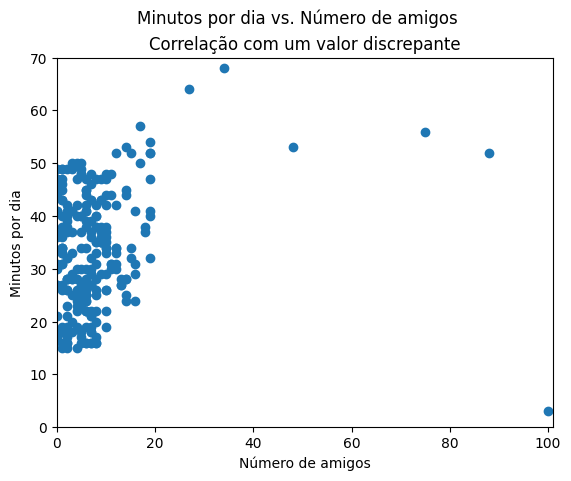

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(num_friends, daily_minutes)
plt.suptitle("Minutos por dia vs. Número de amigos", y=0.98)
plt.title("Correlação com um valor discrepante")
plt.xlim(0, max(num_friends) + 1)
plt.ylim(0, int((max(daily_minutes)+10)/10)*10)
plt.xlabel("Número de amigos")
plt.ylabel("Minutos por dia")
plt.show()

Como a correlação é muito sensível a valores _outliers_, se removemos esse ponto notamos uma mudança considerável no valor da correlação:

In [ ]:
index_outlier      = num_friends.index(100)
num_friends_good   = [x for i,x in enumerate(num_friends) if i != index_outlier]
daily_minutes_good = [y for i,y in enumerate(daily_minutes) if i != index_outlier]

correlation(num_friends_good, daily_minutes_good)

0.31872477280722566

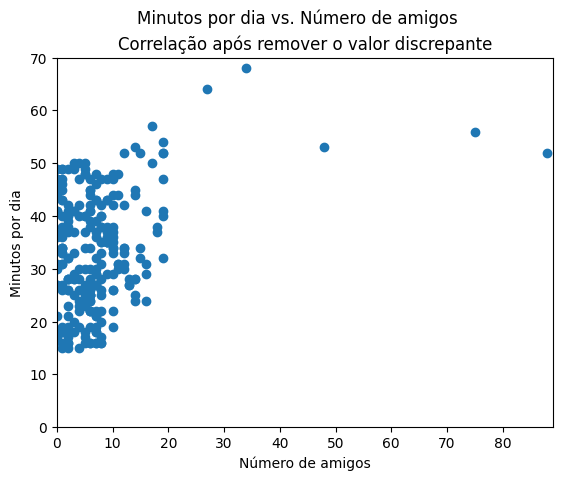

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(num_friends_good, daily_minutes_good)
plt.suptitle("Minutos por dia vs. Número de amigos", y=0.98)
plt.title("Correlação após remover o valor discrepante")
plt.xlim(0, max(num_friends_good) + 1)
plt.ylim(0, int((max(daily_minutes_good)+10)/10)*10)
plt.xlabel("Número de amigos")
plt.ylabel("Minutos por dia")
plt.show()

## 5.3 Paradoxo de Simpson

> _"As correlações podem ser enganosas quando as variáveis de confusão são ignoradas"_

Vamos considerar o caso em que separamos os usuários da plataforma de acordo comm a localidade em que vivem: `'Costa Leste'` e `'Costa Oeste'`, e então verificamos qual dos grupos é mais amigável calculando a quantidade média de amigos.

|localidade|qtd_membros|qtd_media_amigos|
|-|:-:|:-:|
|Costa Oeste|101|8.2|
|Costa Leste|103|6.5|

A partir desses resultados identificamos que os **usuários da Costa Oeste são mais amigáveis**. Porém, ao analisar outras variáveis identificamos algo interessante em relação ao _flag_ `'tem_phd'`:

|localidade|tem_phd|qtd_membros|qtd_amigos|
|-|:-:|:-:|:-:|
|Costa Oeste|1|35|3.1|
|Costa Leste|1|70|3.2|
|Costa Oeste|0|66|10.9|
|Costa Leste|0|33|13.4|

Quando passamos a agrupa os usuários também pelo _flag_ `'tem_phd'` notamos que **os usuários mais amigáveis são da Costa Leste**, tanto para os que tem _PhD_ como para os que não tem _PhD_. Ou seja, a correlação vai em direção oposta do que tinhamos encontrado inicialmente.

Incialmente, quando agrupamos os dados apelas pela localidade, **ocultamos o fato de que os usuários da Costa Leste concentram um maior número de _PhDs_**, e como podemos ver, **usuários com _PhD_ tendem a ser menos amigáveis que usuários sem _PhD_**.

> O ponto chave é que: **"a correlação mede a relação entre duas variáveis _com tudo o mais sendo igual_"**.

Para não incorrermos nesse tipo de conclusão errônea, devemos garantir que **conhecemos os dados** e fazer o máximo possível para **verificar possíveis fatores de confusão**.

## 5.4 Alguns outros pontos de atenção sobre a correlação


### 5.4.1 Correlação zero

Indica que não há relação linear entre as duas variáveis. Mas podem haver vários tipos de relações. Ex.:

In [ ]:
x = [-2, -1, 0, 1, 2]
y = [ 2,  1, 0, 1, 2]
correlation(x, y)

0.0

Cada elemento de `y` é igual ao valor absoluto do correspondente em `x`. Eles só não tem uma relação na qual uma comparação entre `x_i` e `mean(x)` indique algo sobre uma comparação entre `y_i` e `mean(y)`. **Essa é a relação calculada pela correlação**.

### 5.4.2 Tamanho das relações

A correlação não diz nada sobre a maginitude das relações:

In [ ]:
x = [   -2,    -1,   0,      1,      2]
y = [99.98, 99.99, 100, 100.01, 100.02]
correlation(x, y)

1.0

In [ ]:
x = [   -2,    -1, 0,    1,    2]
y = [-0.02, -0.01, 0, 0.01, 0.02]
correlation(x, y)

1.0

In [ ]:
x = [    -2,     -1,    0,       1,       2]
y = [999.98, 999.99, 1000, 1000.01, 1000.02]
correlation(x, y)

1.0

Nos três exeplos acima, `x` e `y` estão perfeitamente correlacionadas. Mas em alguns casos é possível que essa correlação não seja tão interessante assim (algo que depenada do que está sendo medido).

## 5.5 Correlação e causalidade

Se `x` e `y` tem uma forte correlação, isso pode indicar que:

- `x` causa `y`
- `y` causa `x`
- `x` e `y` tem causa mútuas
- ou, cada um é causando por fatores distintos e sua correlação é apenas coincidência.

Considerando novamente o exemplo das amizados. Encontramos uma correlação entre "número de amigos" e "tempo gasto na plataforma", mas não podemos afirmar que há causalidade entre essas duas variáveis.

Podemos listar **hipóteses causais possíveis**:

- É possível que ter mais amigos aumente o tempo que os usuários gastam no site. Se cada amigo postar conteúdos diariamente, então quanto mais amigos, mais tempo será necessário para checar tudo. Nesse caso:
  > mais amigos → mais posts para checar → mais tempo

  Aqui temos "mais posts para checar" com uma variável mediadora, ela é o mecanismo pelo qual uma variável causa a outra.

- Outra hipótese plausível é que os usuários mais assíduos em debates (já passam mais tempo) acabem encontrando pessoas com quem tem afinidade e façam mais amizades. Nesse caso temos uma causalidade entre "passar mais tempo no site" e o "aumento no múmero de amigos".

- Uma terceira possibilidade de explicar erra relação é que os usuários mais dedicados ao tema passem mais tempo no site (porque eles realmente gostam muito disso) e ativamente se associam mais a pessoas com interesse no tema.
  > - interesse pelo tema → mais tempo no site
  > - interesse pelo tema → mais amigos (com interesse em comum)

  Podemos considerar o "interesse pelo tema" como uma variável de confusão, porque essa variável influencia tanto a variavel independete como a dependente, criando uma relação entre elas que não é (diretamente) causal.

**Correlação não implica em causalidade**. Se queremos encarar a causalidade com mais confiança, devemos realizar experimentos: dividindo os usuários aleatóriamente em dois grupos com características demográficas parecidas e adicionando uma experiência um pouco diferente a um dos grupos. Por exemplo, mostrando apenas uma parte do conteúdo dos amigos para um grupo, se esse grupo passar menos tempo no site, então podemos afirmar com mais confiança que há causalidade entre "ter mais amigos" e "passar mais tempo no site".

# Capítulo 6 - Probabilidade

Página 108-124

## 6.0 Resumo

**Dependência e independência de eventos**
- Definição formal de independência: $P(E,F) = P(E)P(F)$

**Probabilidade condicional**
- $P(E|F) = P(E,F)/P(F)$
- O exemplo clássico (e "traiçoeiro") da família com dois filhos — diferença entre condicionar em "o mais velho é menina" (G) vs. "pelo menos um é menina" (L)

**Teorema de Bayes**
- Fórmula para "inverter" probabilidades condicionais
- Conceito de prior (probabilidade a priori) e posterior (probabilidade atualizada após evidência)
- Aplicações práticas: testes médicos, filtros de spam

**Variáveis aleatórias**
- Definição: atribuir valores numéricos a resultados de um processo aleatório
- Distribuição de probabilidade associada a uma variável aleatória
- Valor esperado (esperança matemática) — média ponderada pelas probabilidades
- Linearidade da esperança — esperança de uma soma é a soma das esperanças
- Variáveis aleatórias condicionadas a eventos (reaplicando a família dos dois filhos)

**Distribuições contínuas**
- Diferença entre distribuição discreta e contínua
- Função de densidade de probabilidade (PDF) — probabilidade via integral sobre um intervalo
- Função de distribuição cumulativa (CDF) — probabilidade acumulada até um ponto
- Relação entre PDF e CDF (derivada/integral)
- Distribuição uniforme contínua (ex.: `random.random()`)

**Distribuição normal**
- Parâmetros μ (média) e σ (desvio padrão)
- Distribuição normal padrão ($\mu=0$, $\sigma=1$)
- Padronização (z-score): $Z = (X-\mu)/\sigma$ e sua inversa $X = \sigma Z + \mu$
- CDF normal via função erro (`math.erf`)
- Busca binária para inverter a CDF (encontrar valor a partir de uma probabilidade)

**Teorema do Limite Central (TLC)**
- Soma/média de muitas variáveis i.i.d. (independentes e identicamente distribuídas) se aproxima de uma distribuição normal, independente da distribuição original
- Conexão com a distribuição Binomial (soma de variáveis Bernoulli)
- Aproximação da Binomial pela Normal, com $\mu = np$ e $\sigma = \sqrt{np(1-p)}$
- Correção de continuidade ao aproximar uma distribuição discreta por uma contínua

## 6.2 Probabilidade condicional

In [ ]:
import enum, collections, random

# um Enum eh um conjunto tipado de valores enumerados que deixa o codigo mais descritivo e legivel
class Kid(enum.Enum):
    BOY  = 0
    GIRL = 1

def random_kid() -> Kid:
    return random.choice([Kid.BOY, Kid.GIRL])

both_girls  = 0
older_girl  = 0
either_girl = 0

random.seed(0)
for _ in range(10000):
    younger = random_kid()
    older   = random_kid()

    if older == Kid.GIRL:
        older_girl += 1
    if older == Kid.GIRL and younger == Kid.GIRL:
        both_girls += 1
    if older == Kid.GIRL or younger == Kid.GIRL:
        either_girl += 1

print("P(both | older):", both_girls / older_girl) # ~1/2
print("P(both | either):", both_girls / either_girl) # ~1/3

P(both | older): 0.5007089325501317
P(both | either): 0.3311897106109325


In [ ]:
1/2, 1/3

(0.5, 0.3333333333333333)

## 6.6 A distribuição normal

A distribuição normal se expressa na clássica curva em forma de sino e é totalmente determinada por dois parâmetros:

- sua média $\mu$ (mi): indica onde é o ponto central do sino. Desloca o centro do sino para a esquerda ou direita, sem mudar seu formato.
- seu desvio-padrão $\sigma$ (sigma): indica sua largura. Controla a "largura" do sino, $\sigma$ pequeno = sino estreito e alto (valores concentrados perto da média); $\sigma$ grande = sino largo e achatado (valores mais espalhados).

Ela dispõe da seguinte _função de densidade de probabilidade_ (PDF):

$$ f(x|\mu,\sigma) = \frac{1}{\sqrt{2\pi\sigma}} \text{exp}\left(-\frac{(x-\mu)^2}{2\sigma^2} \right)$$

- $ (x-\mu)^2$: mede o quão longe $x$ está da média. Quanto mais longe, mais essa parte cresce.
- O sinal negativo do expoente da exponencial $e$: transforma "distância grande da média" em "densidade pequena", por isso a curva é alta perto de $\mu$ e cai nas pontas, formando o formato de sino.
- $\sigma^2$ no denominador do expoente: controla **quão rápido** a densidade cai conforme você se afasta da média. Um $\sigma$ pequeno faz a curva cair rapidamente (sino estreito e alto); um $\sigma$ grande faz ela cair devagar (sino largo e achatado).
- $\frac{1}{\sqrt{2\pi\sigma}}$ na frente: é só uma constante de normalização, para garantir que a área total sob a curva seja exatamente 1 (afinal, é uma distribuição de probabilidade).

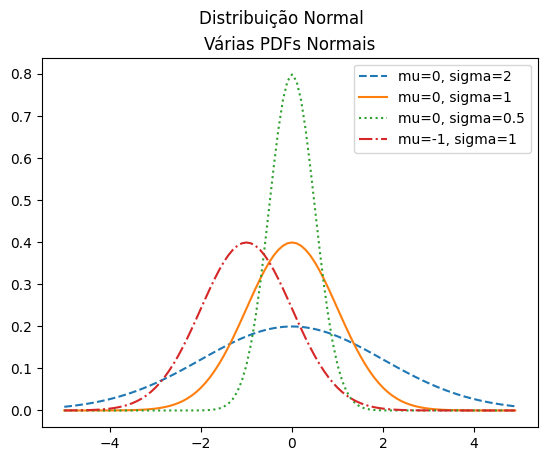

In [ ]:
import math
import matplotlib.pyplot as plt

SQRT_TWO_PI = math.sqrt(2 * math.pi)

def normal_pdf(x: float, mu: float = 0, sigma: float = 1) -> float:
    # mu: media
    # sigma: desvio-padrao
    return (math.exp(-(x-mu) ** 2 / 2 / sigma ** 2) / (SQRT_TWO_PI * sigma))

xs = [x / 10.0 for x in range(-50, 50)]
plt.plot(xs, [normal_pdf(x, sigma=2) for x in xs], '--', label='mu=0, sigma=2')
plt.plot(xs, [normal_pdf(x, sigma=1) for x in xs], '-', label='mu=0, sigma=1')
plt.plot(xs, [normal_pdf(x, sigma=0.5) for x in xs], ':', label='mu=0, sigma=0.5')
plt.plot(xs, [normal_pdf(x, mu=-1) for x in xs], '-.', label='mu=-1, sigma=1')
plt.legend()
plt.suptitle("Distribuição Normal")
plt.title("Várias PDFs Normais")
plt.show()

#### Mas para que serve uma distribuição ser normal, o que ganho com isso?

Uma distribuição normal é completamente descrita por só **dois números** ($\mu$ e $\sigma$). Isso significa que, se você sabe que seus dados são normais, você pode calcular **qualquer probabilidade** sobre eles sem precisar de mais nada, só usando a fórmula da CDF (ou a tabela `erf`, discutida mais abaixo).

Além disso, a normal tem uma famosa regra prática, a **regra empírica (68-95-99,7)**, que diz que:

- aproximadamente 68% dos dados ficam até 1 desvio padrão da média,
- 95% dentro de 2 desvios e
- 99,7% dentro de 3 desvios.

Isso é **útil para identificar outliers rapidamente**, por exemplo: "esse valor está a mais de 2 desvios da média, é incomum". Mas só funciona de verdade se os dados forem _realmente_ normais.

### A padronização

A _distribuição normal padrão_ ocorre quando $\mu = 0$ e $\sigma = 1$. **Qualquer** variável normal $\text{X}$ (com média $\mu$ e desvio $\sigma$ quaisquer) pode ser transformada numa normal **padrão** $\text{Z}$ (média 0, desvio 1) através de:

$$\text{Z} = \frac{\text{X} - \mu}{\sigma}$$

O que essa fórmula faz, passo a passo:

- $\text{X} - \mu$: desloca os dados para que a média fique em $0$ (é exatamente a "centralização", sobre subtrair a média).
- Dividir por $\sigma$: reescala os dados para que o desvio padrão fique em $1$.

E o caminho inverso, $\text{X} = \sigma\text{Z} + \mu$, desfaz essa transformação: pega uma variável padrão e "estica"/"desloca" ela de volta para ter a média e desvio que você quiser.

#### Por que isso é útil na prática

Essa transformação (chamada de **$z$-score** ou **padronização**) permite comparar variáveis de escalas completamente diferentes.

Por exemplo, se você quer comparar "quão excepcional" foi uma nota de prova (média 70, desvio 10) com "quão excepcional" foi um salário (média R$5.000, desvio R$1.500), você não pode comparar os números brutos, mas pode comparar os $z$-scores.

Um $z$-score de +2 significa, em qualquer distribuição normal, "2 desvios padrão acima da média", e isso é diretamente comparável entre variáveis diferentes.

### A CDF via `erf`

A _função de distribuição cumulativa_ CDF da normal (que é a $\int$ da PDF) não pode ser escrita usando funções elementares como polinômios, exponenciais, senos e etc., só existe como uma integral que precisa ser aproximada numericamente.

A função erro ([`erf`](https://pt.wikipedia.org/wiki/Fun%C3%A7%C3%A3o_erro)) é uma função especial, tabelada/implementada numericamente, que resolve exatamente esse tipo de integral. Abaixo expressamos a CDF normal em termos de `math.erf` implementada na biblioteca padrão do Python:


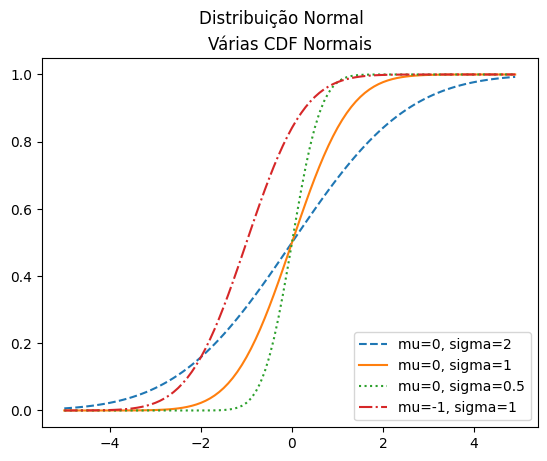

In [ ]:
def normal_cdf(x: float, mu: float = 0, sigma: float = 1) -> float:
    return (1 + math.erf((x - mu) / math.sqrt(2) / sigma)) / 2

xs = [x / 10.0 for x in range(-50, 50)]
plt.plot(xs, [normal_cdf(x, sigma=2) for x in xs], '--', label='mu=0, sigma=2')
plt.plot(xs, [normal_cdf(x, sigma=1) for x in xs], '-', label='mu=0, sigma=1')
plt.plot(xs, [normal_cdf(x, sigma=0.5) for x in xs], ':', label='mu=0, sigma=0.5')
plt.plot(xs, [normal_cdf(x, mu=-1) for x in xs], '-.', label='mu=-1, sigma=1')
plt.legend(loc=4)
plt.suptitle("Distribuição Normal")
plt.title("Várias CDF Normais")
plt.show()

#### Por que precisamos de busca binária para inverter a CDF

A CDF é usada para responder a pergunta: "dado um valor $x$, qual a probabilidade acumulada até ali? ".

Mas às vezes a pergunta é ao contrário: "dado que eu quero uma probabilidade acumulada de 95%, qual é o valor de $x$ que corresponde a isso?". Essa é a CDF inversa (também chamada de _função quantil_).

Como não existe fórmula fechada para a CDF normal (por causa do `erf`), também não existe fórmula fechada para invertê-la. como a CDF é contínua e estritamente crescente (nunca "desce"), podemos usar a [busca binária](https://pt.wikipedia.org/wiki/Pesquisa_bin%C3%A1ria):

In [ ]:
def inverse_normal_cdf(p: float,
                       mu: float = 0,
                       sigma: float = 1,
                       tolerance: float = 0.00001) -> float:
    """
    Encontra o inverso aproximado da CDF normal usando pesquisa binaria.
    """
    # se nao for normal padrao, computa o padrao e redimensiona
    if mu != 0 or sigma != 1:
        return mu + sigma * inverse_normal_cdf(p, tolerance=tolerance)

    # 1) parte de um intervalo grande, que sabemos que a resposta certa esta dentro
    low_z = -10.0                       # normal_cdf(-10) (eh muito proxima de) 0
    hi_z  =  10.0                       # normal_cdf(+10) (eh muito proxima de) 1

    while hi_z - low_z > tolerance:

        # 2) testa  ponto medio
        mid_z = (low_z + hi_z) / 2      # considere o ponto medio
        mid_p = normal_cdf(mid_z)       # e o valor da CDF

        # 3) compara o resultado com a probabilidade dada
        if mid_p < p:
            # valor da CDF eh MENOR que a probabilidade desejada
            # o ponto medio eh muito baixo, procure um maior
            low_z = mid_z
        elif mid_p > p:
            # valor da CDF eh MAIOR que a probabilidade desejada
            # o ponto medio eh muito alto, procure um menor
            hi_z = mid_z
        else:
            break

    return mid_z

A função divide os intervalos em dois várias vezes até chegar a um $\text{Z}$ suficientemente próximo da probabilidade desejada.

## 6.7 O Teorema do Limite Central

O TLC diz: não importa qual seja o formato da distribuição original (pode ser feia, torta, discreta, o que for), se você **repetir o experimento N vezes e tirar a média** (ou soma) dos resultados, essa média vai ter uma distribuição parecida com um sino (normal), e esse efeito fica mais forte quanto mais repetições você usar.

O ponto chave que costuma confundir: **existem duas distribuições diferentes envolvidas**, e é fácil misturá-las:
1. A distribuição **de cada dado individual/observação isolada** (não precisa ser normal, quase nunca é).
2. A distribuição **da média de várias observações** (essa sim se aproxima de normal).

Vamos ver os três exemplos gerando essa comparação lado a lado.Agora, olhando o gráfico, vamos passar por cada exemplo com calma, comparando **linha de cima** (distribuição original, de UMA observação) com **linha de baixo** (distribuição da média de 30 observações).

#### **Exemplo: Dado**

*Linha de cima:* jogue **um** dado uma vez. O resultado pode ser 1, 2, 3, 4, 5 ou 6 — todos igualmente prováveis. É uma distribuição **reta/uniforme**, sem sino nenhum.

*Linha de baixo:* agora jogue **30 dados** e calcule a **média** desses 30 resultados. Repita esse processo (30 jogadas + média) 5.000 vezes, e veja como essas 5.000 médias se distribuem. Repare que a média de 30 dados quase nunca vai dar 1 ou 6 (seria preciso os 30 dados darem quase todos 1, ou quase todos 6 — extremamente improvável). Ela tende a ficar perto de 3,5 (que é a média teórica de um dado: $(1+2+3+4+5+6)/6 = 3,5$), e a curva formada por essas médias já é bem parecida com um sino.

#### **Exemplo: Bernoulli (moeda)**

*Linha de cima:* jogue **uma** moeda. O resultado só pode ser 0 (coroa) ou 1 (cara) — literalmente só duas barrinhas, sem nenhum "meio". É a distribuição mais "não-normal" possível.

*Linha de baixo:* jogue a moeda **30 vezes** e calcule a **proporção de caras** nesses 30 lançamentos (essa proporção é a "média" de 30 zeros e uns). Repita 5.000 vezes. Cada vez que fizer isso, você vai obter um valor entre 0 e 1 (ex.: 14 caras em 30 = 0,467). A distribuição dessas proporções fica com formato de sino, centrada em 0,5 (que é a probabilidade $p$ da moeda).

**Conexão direta com o que já vimos:** essa "média de 30 lançamentos" é exatamente a mesma coisa que a variável **Binomial(30, 0,5) dividida por 30** — o mesmo exemplo do `bernoulli_trial` e `binomial(n,p)` do livro, só que aqui olhando a *proporção* em vez da *contagem* de caras.

#### **O padrão que se repete**

Repare que a "matéria-prima" de cada exemplo é **completamente diferente**:
- Dado: 6 valores discretos, uniforme
- Moeda: só 2 valores possíveis (0 ou 1)

Mas em **todos os três**, o resultado da linha de baixo (média de 30 repetições) é parecido com um sino. Isso é o TLC funcionando: **independente da forma da distribuição original**, a distribuição da média de várias repetições converge para uma normal, desde que:
1. As observações sejam independentes umas das outras (um dado não afeta o outro; uma conta de um cliente não afeta a de outro),
2. Você tenha um número razoável de repetições sendo somadas/mediadas (aqui usamos 30, que já costuma ser suficiente na prática).

Abaixo é demonstrado o exemplo da moeda:

In [ ]:
def bernoulli_trial(p: float) -> int:
    # retorna 1 com probabilidade p e 0 com probabilidade 1-p
    return 1 if random.random() < p else 0

def binomial(n: int, p: float) -> int:
    # retorna a soma de n trials de bernoulli(p), uma amostra de n lancamentos
    return sum(bernoulli_trial(p) for _ in range(n))

In [ ]:
# jogando a moeda 5 vezes
binomial(5, 0.5)

3

In [ ]:
# jogando a moeda 10 vezes
binomial(10, 0.5)

6

In [ ]:
# jogando a moeda 20 vezes
binomial(20, 0.5)

17

In [ ]:
# jogando a moeda 50 vezes
binomial(50, 0.5)

26

In [ ]:
# jogando a moeda 100 vezes
binomial(100, 0.5)

47

In [ ]:
from collections import Counter

def binomial_histogram(p: float, n: int, num_points: int) -> None:
    data = [binomial(n, p) for _ in range(num_points)]
    histogram = Counter(data)

    plt.bar([x - 0.4 for x in histogram.keys()],
            [v / num_points for v in histogram.values()],
            0.8,
            color='0.75')

    # aproximacao da normal
    mu = p * n
    sigma = math.sqrt(n * p * (1 - p))

    xs = range(min(data), max(data) + 1)
    ys = [normal_cdf(i + 0.5, mu, sigma) - normal_cdf(i - 0.5, mu, sigma) for i in xs]
    plt.plot(xs, ys, label=f"mu={mu:.2f}, sigma={sigma:.2f}")
    plt.legend()
    plt.title(f"Distribuição Binomial ({n} trials, {num_points} pontos) vs Aproximação Normal")
    plt.show()

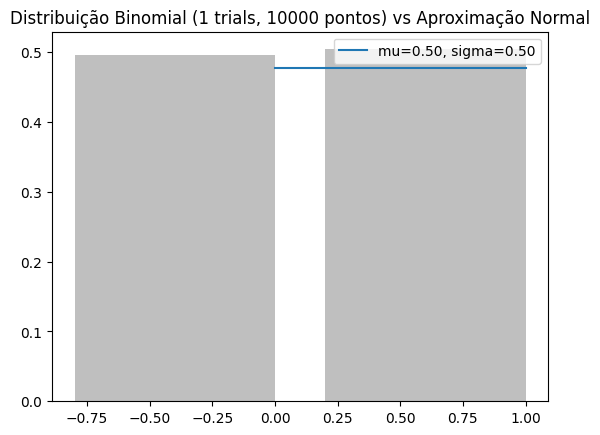

In [ ]:
binomial_histogram(0.5, 1, 10000)

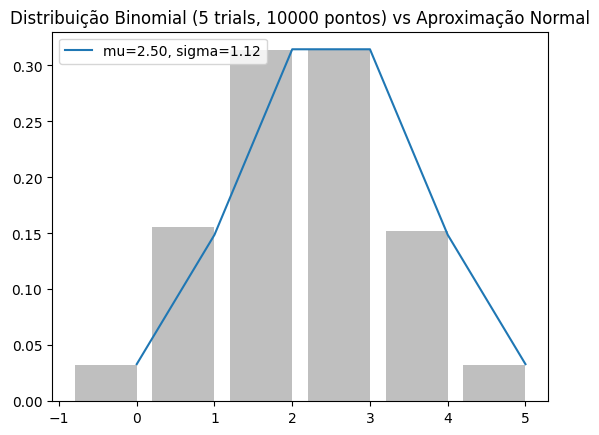

In [ ]:
binomial_histogram(0.5, 5, 10000)

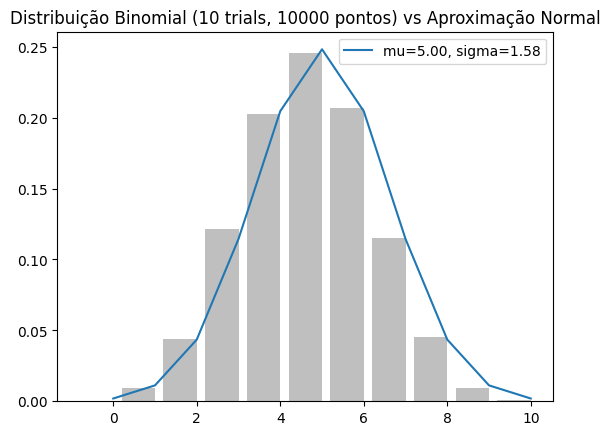

In [ ]:
binomial_histogram(0.5, 10, 10000)

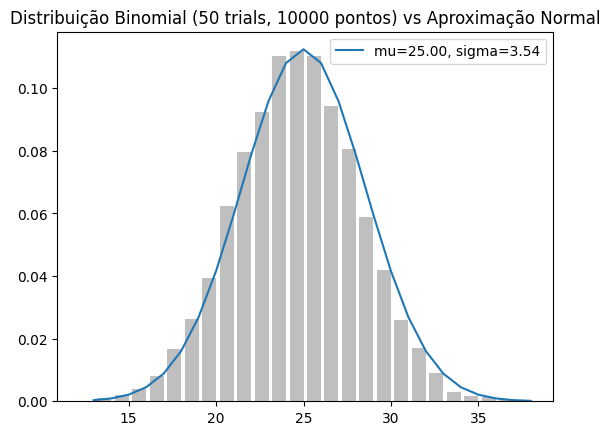

In [ ]:
binomial_histogram(0.5, 50, 10000)

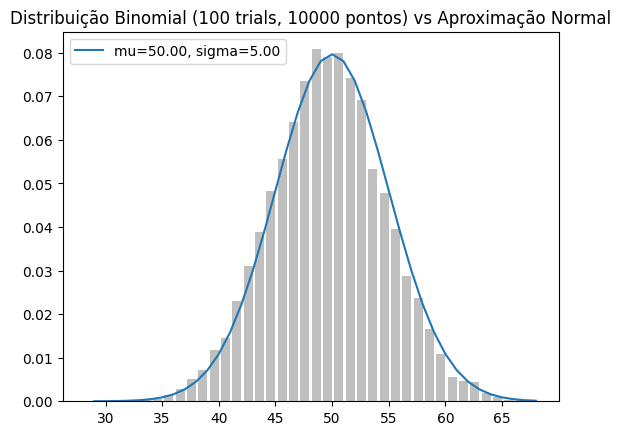

In [ ]:
binomial_histogram(0.5, 100, 10000)

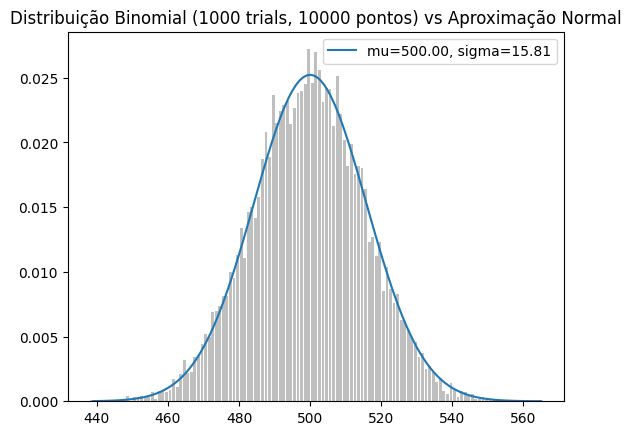

In [ ]:
binomial_histogram(0.5, 1000, 10000)

Quando você soma/tira a média de várias variáveis, os valores "do meio" podem ser alcançados de **muito mais formas diferentes** do que os valores extremos.

Por exemplo, uma média de 30 dados próxima de $3,5$ pode vir de inúmeras combinações diferentes de resultados (alguns dados altos compensando outros baixos), enquanto uma média muito próxima de 1 exigiria que quase todos os 30 dados dessem 1, que é extremamente raro, considerando que é um dado honesto.

Esse acúmulo de "muitos caminhos levando ao meio, poucos caminhos levando aos extremos" é o que esculpe o formato de sino. E isso vale igualmente para dado, moeda, ou qualquer que seja a natureza específica da variável, só importa que você está **somando/tirando a média de muitas delas de forma independente**.

# Exemplo prático



## Dataset `tips`

Vamos praticar os conceitos vistos nesses dois capítulos utilizando o dataset [tips](https://www.kaggle.com/datasets/sakshisatre/tips-dataset), que pode ser obtido diretamente da biblioteca Seaborn.

- `total_bill`: Cost of the meal in dollars, including the cost of food and drinks (numeric).
- `tip`: Tip given in dollars (numeric).
- `sex`: Gender of the person paying the bill (categorical: Male, Female).
- `smoker`: If the party has smokers (categorical: Yes, No).
- `day`: Day of the week (categorical: Thur, Fri, Sat, Sun).
- `time`: Meal period (categorical: Lunch, Dinner).
- `size`: Number of people in the party (numeric)


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# import os
# os.chdir("/content/drive/MyDrive/Colab Notebooks/data_science_do_zero")

# df = pd.read_csv('datasets/tips.csv')
df = sns.load_dataset("tips")
print(df.shape)
df.head()

(244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# df['prop_tip_bill'] = round(df['tip'] / (df['total_bill'] - df['tip']), 2) # considerando que a gorjeta foi adicionada no custo total
df['perc_tip_bill'] = round(df['tip'] / df['total_bill'], 2)
print(df.shape)
df.head()

(244, 8)


,total_bill,tip,sex,smoker,day,time,size,perc_tip_bill
0,16.99,1.01,Female,No,Sun,Dinner,2,0.06
1,10.34,1.66,Male,No,Sun,Dinner,3,0.16
2,21.01,3.50,Male,No,Sun,Dinner,3,0.17
3,23.68,3.31,Male,No,Sun,Dinner,2,0.14
4,24.59,3.61,Female,No,Sun,Dinner,4,0.15


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   total_bill     244 non-null    float64 
 1   tip            244 non-null    float64 
 2   sex            244 non-null    category
 3   smoker         244 non-null    category
 4   day            244 non-null    category
 5   time           244 non-null    category
 6   size           244 non-null    int64   
 7   perc_tip_bill  244 non-null    float64 
dtypes: category(4), float64(3), int64(1)
memory usage: 9.3 KB


## Estatística descritiva

In [ ]:
describe = df.describe()
describe.round(2)

,total_bill,tip,size,perc_tip_bill
count,244.00,244.00,244.00,244.00
mean,19.79,3.00,2.57,0.16
std,8.90,1.38,0.95,0.06
min,3.07,1.00,1.00,0.04
25%,13.35,2.00,2.00,0.13
50%,17.80,2.90,2.00,0.16
75%,24.13,3.56,3.00,0.19
max,50.81,10.00,6.00,0.71


In [ ]:
quantile(df['total_bill'], 0.25)

13.37

In [ ]:
quantile(df['tip'], 0.5)

2.92

In [ ]:
[(i, mode(df[i])[0]) for i in describe.columns]

[('total_bill', 13.42), ('tip', 2.0), ('size', 2), ('perc_tip_bill', 0.14)]

In [ ]:
linhas = []
for i in describe.columns:
    media, mediana = describe.loc['mean',i], describe.loc['50%',i]
    linhas.append({'media':    round(media, 2),
                   'mediana':  round(mediana, 2),
                   'var_perc': round((media - mediana)/media, 2)})

pd.DataFrame(linhas, index=describe.columns)

,media,mediana,var_perc
total_bill,19.79,17.80,0.10
tip,3.00,2.90,0.03
size,2.57,2.00,0.22
perc_tip_bill,0.16,0.16,0.04


Rodando um `describe` no DataFrame observamos que as variáveis `tota_bill` e `size` possuem média (19,79 e 2,57) maior que a mediada (17,80 e 2,00), o que pode ser indício de assimetria a direita. Essa assimetria pode ser observada nos gráficos abaixo, em que vemos claramente algumas contas mais altas puxando a média para cima.

A variável `tip` também não possui exatamente o mesmo valor, mas a diferença é pequena, apenas 3%, e no gráfico abaixo vemos que a linha representando a média fica muito mais próxima da linha da mediana.

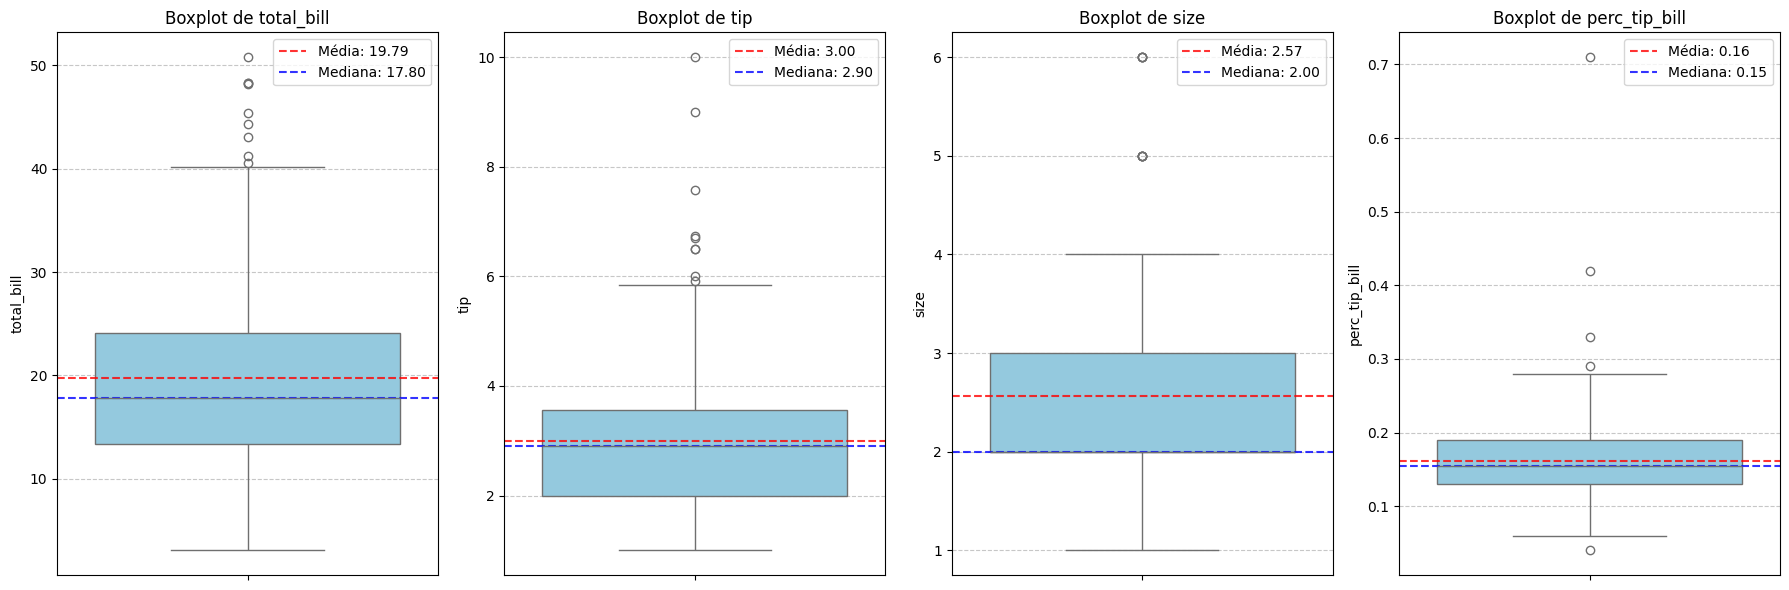

In [ ]:
# Create a figure with three subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# Plot each numerical column as a boxplot in its respective subplot
for i, col in enumerate(describe.columns):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    # Calculate the mean for the current column
    mean_value = df[col].mean()
    median_value = df[col].median() # deixa sem arredondar mesmo
    # Add a horizontal dashed line
    axes[i].axhline(mean_value, color='red', linestyle='--', alpha=0.8, linewidth=1.5, label=f'Média: {mean_value:.2f}')
    axes[i].axhline(median_value, color='blue', linestyle='--', alpha=0.8, linewidth=1.5, label=f'Mediana: {median_value:.2f}')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].legend()

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

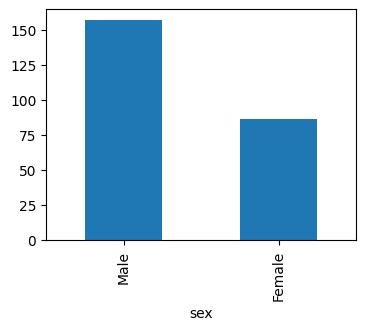

In [ ]:
_ = df['sex'].value_counts().plot(kind='bar', figsize=(4,3))

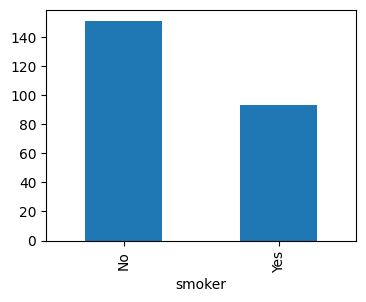

In [ ]:
_ = df['smoker'].value_counts().plot(kind='bar', figsize=(4,3))

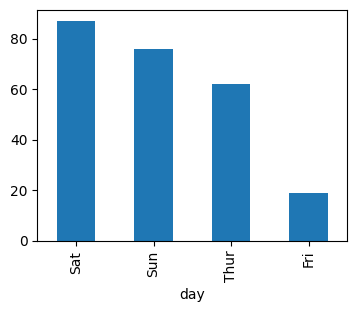

In [ ]:
_ = df['day'].value_counts().plot(kind='bar', figsize=(4,3))

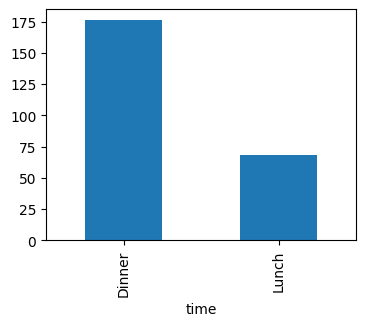

In [ ]:
_ = df['time'].value_counts().plot(kind='bar', figsize=(4,3))

### Dispersão

Quando avaliamos a dispersão dos dados queremos entender como os dados estão distribuídos. Temos várias medidas para expressar isso, em todas quanto mais próximo de zero o valor, melhor.

In [ ]:
linhas = []
for i in describe.columns:
    linhas.append({'data_range': data_range(df[i]), # amplitude dos dados
                   'variance': variance(df[i]), # medida de como a variavel desvia da media (unidade: variavel^2)
                   'standard_deviation': standard_deviation(df[i]), # raiz quadrada da variancia
                   'diff_quantil_75_25': interquartile_range(df[i]), # diferenca entre valores de 75% e 25% perncentis
                   })

pd.DataFrame(linhas, index=describe.columns)

,data_range,variance,standard_deviation,diff_quantil_75_25
total_bill,47.74,79.252939,8.902412,10.90
tip,9.00,1.914455,1.383638,1.60
size,5.00,0.904591,0.951100,1.00
perc_tip_bill,0.67,0.003725,0.061030,0.06


## Correlação

In [ ]:
covariance(df['total_bill'], df['tip'])

8.323501629224854

In [ ]:
# matriz de covariancia
linhas = [{i: covariance(df[i], df[j]) for i in describe.columns} for j in describe.columns]

pd.DataFrame(linhas, index=describe.columns)

,total_bill,tip,size,perc_tip_bill
total_bill,79.252939,8.323502,5.065983,-0.181875
tip,8.323502,1.914455,0.643906,0.029039
size,5.065983,0.643906,0.904591,-0.008194
perc_tip_bill,-0.181875,0.029039,-0.008194,0.003725


In [ ]:
# matriz de correlacao
linhas = [{i: correlation(df[i], df[j]) for i in describe.columns} for j in describe.columns]

pd.DataFrame(linhas, index=describe.columns)

,total_bill,tip,size,perc_tip_bill
total_bill,1.000000,0.675734,0.598315,-0.334753
tip,0.675734,1.000000,0.489299,0.343895
size,0.598315,0.489299,1.000000,-0.141157
perc_tip_bill,-0.334753,0.343895,-0.141157,1.000000


In [ ]:
# matriz de correlacao
df.corr(method='pearson', numeric_only=True) # method: 'pearson', 'spearman', 'kendall'

,total_bill,tip,size,perc_tip_bill
total_bill,1.000000,0.675734,0.598315,-0.334753
tip,0.675734,1.000000,0.489299,0.343895
size,0.598315,0.489299,1.000000,-0.141157
perc_tip_bill,-0.334753,0.343895,-0.141157,1.000000


Alguns pontos que observamos a partir das correlações:
- a maior **correlação positiva** que observamos é entre o "valor da conta" e a "gorjeta",  o que faz sentido, já que geralmente a gorjeta é um percentual da conta
- mas quando olhamos para a correlação entre valor da conta e o percentual da gorjeta, notamos uma correlação negativa fraca. Ou seja, a medida que o valor da conta sobe, o percentual da gorjeta diminui
- outra correlação positiva que temos é em relação ao tamanho da mesa e o custo, tanto a conta como a gorjeta

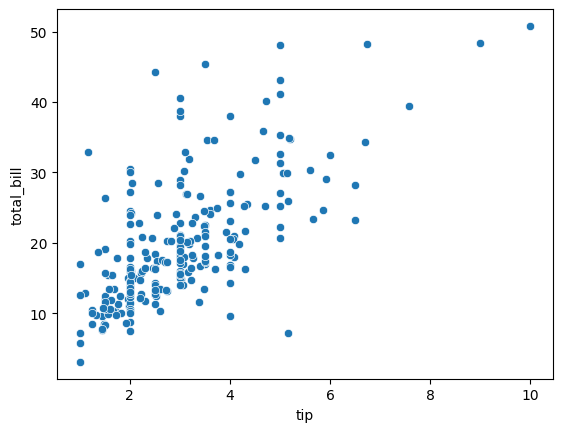

In [ ]:
_ = sns.scatterplot(x=df['tip'], y=df['total_bill'])

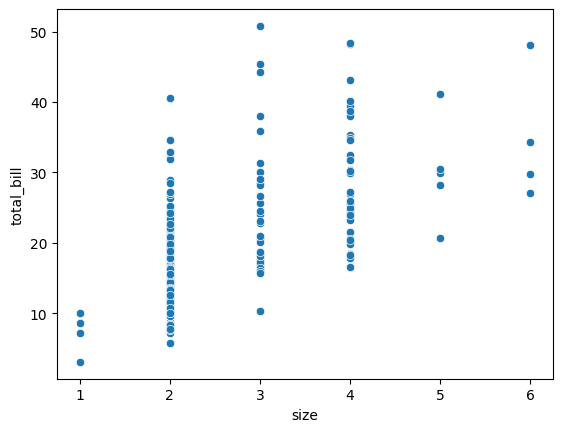

In [ ]:
_ = sns.scatterplot(x=df['size'], y=df['total_bill'])

### Mais gráficos de dispersão

In [ ]:
# seleciona combinacoes para graficos
combinacoes = []
for i in describe.columns:
    for j in describe.columns:
        if i != j:
            combinacao = tuple(sorted([i,j])) # porque quero que seja tupla
            if combinacao not in combinacoes:
                combinacoes.append(combinacao)

combinacoes

[('tip', 'total_bill'),
 ('size', 'total_bill'),
 ('perc_tip_bill', 'total_bill'),
 ('size', 'tip'),
 ('perc_tip_bill', 'tip'),
 ('perc_tip_bill', 'size')]

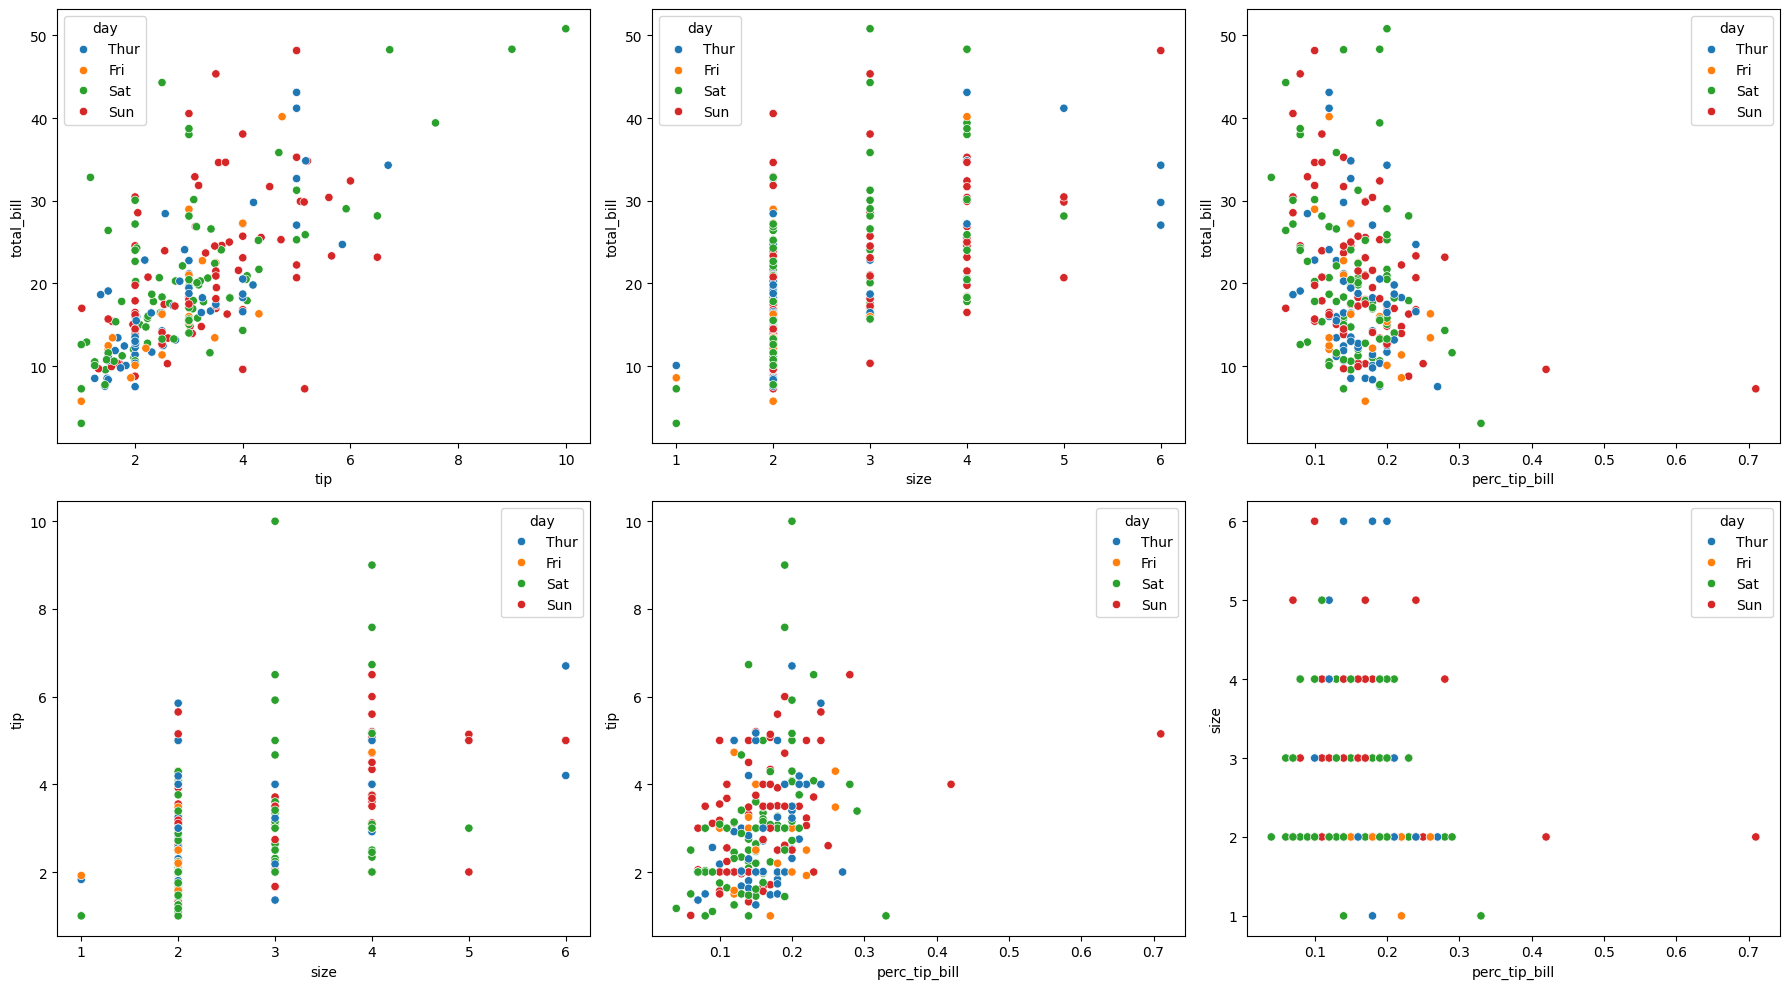

In [ ]:
# verifica as distribuicoes abrindo pelo dia
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (var_x, var_y) in enumerate(combinacoes):
    sns.scatterplot(x=df[var_x],
                    y=df[var_y],
                    hue=df['day'],
                    ax=axes[0 if i < 3 else 1][i if i < 3 else i-3])

plt.tight_layout()
plt.show()

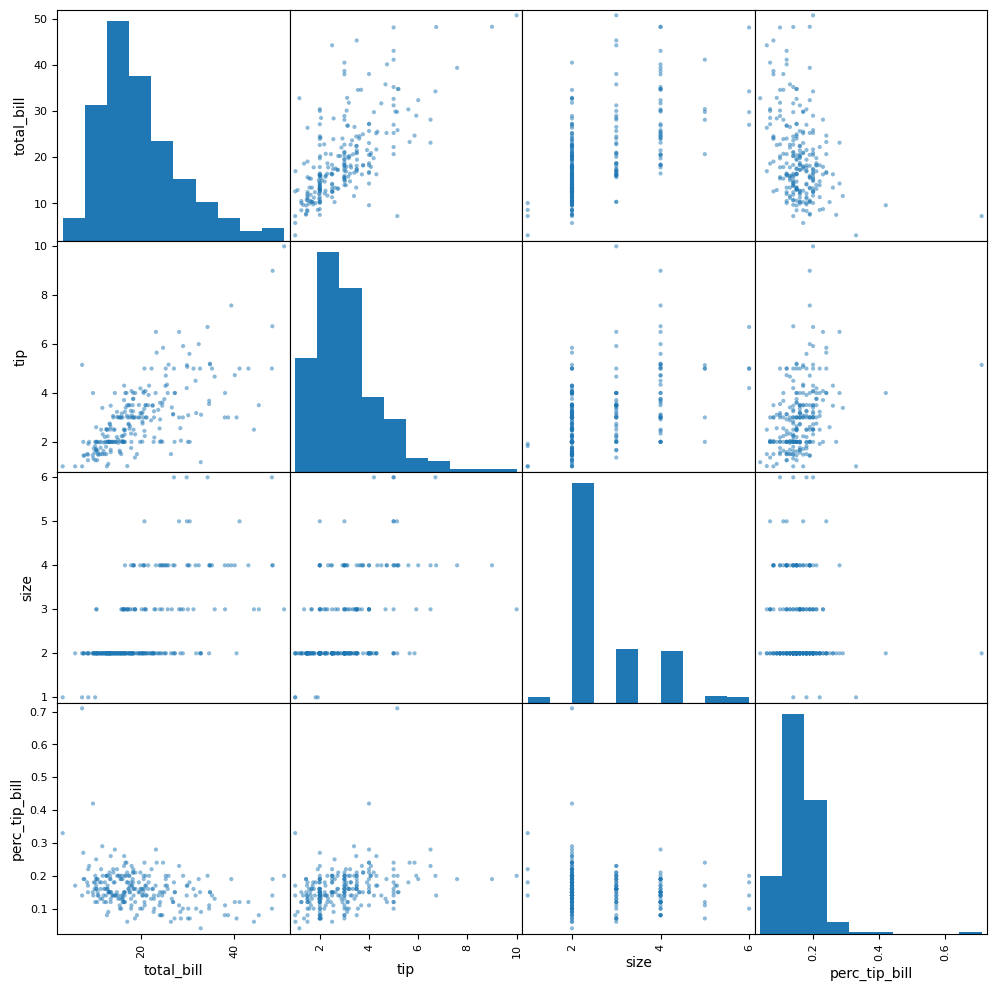

In [ ]:
_ = pd.plotting.scatter_matrix(df, figsize=(12, 12))

## Probabilidade

### Dependência e independência de eventos

In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size,perc_tip_bill
0,16.99,1.01,Female,No,Sun,Dinner,2,0.06
1,10.34,1.66,Male,No,Sun,Dinner,3,0.16
2,21.01,3.50,Male,No,Sun,Dinner,3,0.17
3,23.68,3.31,Male,No,Sun,Dinner,2,0.14
4,24.59,3.61,Female,No,Sun,Dinner,4,0.15


Vamos utilizar a definição formal de independência para verificar qual é o tipo de relação entre os eventos "ser fumante" e "jantar".

$$P(E,F)=P(E) \cdot P(F)$$

Começamos encontrando as probabilidades de cada um dos eventos acontecer separadamente:

In [ ]:
df['smoker'].value_counts(normalize=True)

,proportion
smoker,
No,0.618852
Yes,0.381148


In [ ]:
# proporcao de fumantes
_, prop_smoker = df['smoker'].value_counts(normalize=True).values
prop_smoker

np.float64(0.38114754098360654)

In [ ]:
prop_time = df['time'].value_counts(normalize=True)
prop_time

,proportion
time,
Dinner,0.721311
Lunch,0.278689


In [ ]:
# proporcao de jantares
prop_dinner, _ = prop_time.values
prop_dinner

np.float64(0.7213114754098361)

E então calculamos a probabilidade esperada para os dois eventos acontecerem ao mesmo tempo, sob a condição de independência entre eles:

In [ ]:
# probabilidade esperada sob indepencia
prop_esperada_independecia = prop_smoker * prop_dinner
prop_esperada_independecia

np.float64(0.2749260951357162)

Após isso calculamos o valor observado para probabilidade dos dois eventos acontecerem simultâneamente e comparamos os valores:

In [ ]:
prop_smoker_time = df.groupby(['time', 'smoker'], observed=True).size() / len(df)
print(prop_smoker_time)

time    smoker
Lunch   Yes       0.094262
        No        0.184426
Dinner  Yes       0.286885
        No        0.434426
dtype: float64


In [ ]:
# proporcao de jantares de fumantes
prop_smoker_and_dinner = prop_smoker_time.loc[('Dinner', 'Yes')]
prop_smoker_and_dinner

np.float64(0.28688524590163933)

In [ ]:
prop_esperada_independecia == prop_smoker_and_dinner

np.False_

Observamos que os valores são próximos, mas não iguais, e portanto, não podemos afirmar que "ser fumante" e estar no "jantar" são eventos independentes.

Uma forma direta de quantificar o quanto os dados se desviam da independência é calcular a razão entre a probabilidade conjunta observada e a que seria esperada sob independência:

$$\text{lift} = \frac{P(E,F)_{\text{observado}}}{P(E) \cdot P(F)_{\text{esperado sob independência}}}$$

Se $\text{lift} = 1$, os eventos são exatamente independentes, quanto mais distante de 1, mais forte a dependência. A magnitude do desvio em relação a 1 indica a força da dependência, independente da direção. Mas a direção (acima ou abaixo de 1) também carrega informação importante:

- $\text{lift} > 1$: os eventos ocorrem juntos mais do que o esperado por acaso — associação positiva (um "favorece" o outro).
- $\text{lift} < 1$: os eventos ocorrem juntos menos do que o esperado — associação negativa (um "inibe" o outro, eles tendem a se evitar).
- $\text{lift} = 1$: independência perfeita.

In [ ]:
lift = prop_smoker_and_dinner / prop_esperada_independecia
lift

np.float64(1.0434995112414467)

O resultado acima mostra que a probabilidade conjunta observada é apenas $4,3%$ maior do que seria esperado se os eventos fossem independentes.

Uma ressalva deve ser feita em relação a escala do $\text{lift}$: ela não é simétrica em torno de 1.

$\text{Lift} = 2$ significa "duas vezes mais provável que o esperado" (associação forte e positiva). Mas $\text{lift} = 0,5$ significa "metade do esperado", uma associação igualmente forte, só que negativa.

Porém, numericamente, $2-1=1$ enquanto $1-0,5=0,5$, a distância bruta até 1 não reflete a mesma "força" nos dois casos, porque o $\text{lift}$ só pode variar de 0 a infinito (nunca fica negativo). Então o intervalo abaixo de 1 é "espremido" em $[0,1]$, enquanto acima de 1 se estende até o infinito.

Por isso, quando você quer comparar a força de diferentes dependências de forma justa (independente da direção), é comum usar
$log⁡(\text{lift})$ em vez do $\text{lift}$ bruto. Isso torna a escala simétrica ao redor de 0 (0 = independência, positivo = associação positiva, negativo = associação negativa, e valores com o mesmo módulo representam forças equivalentes).

In [ ]:
from math import log

log(lift)

0.0425799791511531

### Teorema de Bayes

Agora vamos aplicar o **Teorema de Bayes** para calcular $P(\text{jantar}|\text{fumante})$: a probabilidade do cliente estar no jantar, sabendo que ele é fumante.

Faremos isso invertendo a condicional, a partir de informações que já temos na direção "inversa" $P(\text{fumante}|\text{jantar})$: a probabilidade de ser fumante, dado que é um jantar.

A fórmula completa do teorema é:

$$P(E|F) = \frac{P(F|E)\cdot P(E)}{P(F|E)\cdot P(E) + P(F|\lnot E)\cdot P(\lnot E)}$$

Onde, no nosso caso:

- $E$ → _"a conta é do jantar"_
- $\lnot E$ → _"a conta é do almoço"_
- $F$ → _"o cliente é fumante"_


#### 1. $P(E)$: o **prior** de "jantar"

É a probabilidade de uma conta qualquer ser do jantar, **sem nenhuma informação adicional** sobre o cliente (não sabemos se é fumante ou não).

**Racional para o valor:** é simplesmente a proporção de contas de jantar no dataset inteiro, não envolve a variável "fumante" de forma alguma.

$$P(E) = \frac{n_{\text{jantar}}}{n_{\text{total}}} = \frac{176}{244} = 0,7213$$


In [ ]:
df['time'].value_counts()

,count
time,
Dinner,176
Lunch,68


In [ ]:
df['time'].value_counts().loc['Dinner'] / len(df)

np.float64(0.7213114754098361)

In [ ]:
prop_dinner

np.float64(0.7213114754098361)

#### 2. $P(\lnot E)$: o prior de "almoço"

É o complemento do item anterior, a probabilidade da conta ser do almoço.

Como só existem duas categorias (jantar ou almoço), podemos calcular a probabilidade de "não $E$" como $P(\lnot E) = 1 - P(E)$, ou equivalentemente, usando a razão da contagem direta de almoços sobre o total:

$$P(\lnot E) = \frac{n_{\text{almoço}}}{n_{\text{total}}} = \frac{68}{244} = 0,2787$$


In [ ]:
prop_lunch = 1 - prop_dinner
prop_lunch

np.float64(0.2786885245901639)

#### 3. $P(F|E)$: a probabilidade de ser fumante, **dado** que é jantar

Dentro do subgrupo "contas de jantar", qual fração é de fumantes.

Aqui já não dividimos mais pelo total geral (244), e sim **pelo total de jantares** (176), porque estamos "restringindo o universo" só para dentro do evento $E$. Você filtra o universo e recalcula a proporção dentro dele.

$$P(F|E) = \frac{n_{\text{fumante e jantar}}}{n_{\text{jantar}}} = \frac{70}{176} = 0,3977$$


In [ ]:
df_dinner             = df[df['time'] == 'Dinner']
prop_smoker_if_dinner = df_dinner['smoker'].value_counts().loc['Yes'] / len(df_dinner)
prop_smoker_if_dinner

np.float64(0.3977272727272727)

#### 4. $P(F|\lnot E)$: a probabilidade de ser fumante, **dado** que é almoço

Segue a mesma lógica do item anterior, mas agora restringindo o universo ao subgrupo "almoço" em vez de "jantar".

Contamos quantos fumantes temos no almoço (23) e dividimos pelo total de almoços (68), não pelo total geral.

$$P(F|\lnot E) = \frac{n_{\text{fumante e almoço}}}{n_{\text{almoço}}} = \frac{23}{68} = 0,3382$$

In [ ]:
df_lunch             = df[df['time'] == 'Lunch']
prop_smoker_if_lunch = df_lunch['smoker'].value_counts().loc['Yes'] / len(df_lunch)
prop_smoker_if_lunch

np.float64(0.3382352941176471)

#### 5. $P(F)$: a probabilidade total de ser fumante

É a probabilidade de um cliente do restaurante ser fumante, olhando para o dataset inteiro, sem restringir a jantar ou almoço. — mas aqui, em vez de calcular direto ($93/244$),

$$P(F) = \frac{n_{\text{fumante}}}{n_{\text{total}}} = \frac{93}{244} = 0,3811$$

In [ ]:
df['smoker'].value_counts()

,count
smoker,
No,151
Yes,93


In [ ]:
prop_smoker = df['smoker'].value_counts().loc['Yes'] / len(df)
prop_smoker

np.float64(0.38114754098360654)

Também podemos **reconstruir** $P(F)$ a partir dos itens já calculados (1 a 4), usando a **lei da probabilidade total**.

Todo fumante do dataset está **ou** no grupo do jantar **ou** no grupo do almoço, essas duas possibilidades são mutuamente exclusivas e cobrem todos os casos. Então podemos "montar" $P(F)$ somando a contribuição de cada pedaço:

$$P(F) = \underbrace{P(F|E)\cdot P(E)}_{\text{contribuição do jantar}} + \underbrace{P(F|\lnot E)\cdot P(\lnot E)}_{\text{contribuição do almoço}}$$

$$P(F) = \underbrace{(0,3977) \cdot (0,7213)}_{\text{contribuição do jantar}} + \underbrace{(0,3382) \cdot (0,2786)}_{\text{contribuição do almoço}} = 0,3811$$

In [ ]:
(prop_smoker_if_dinner * prop_dinner) + (prop_smoker_if_lunch * prop_lunch)

np.float64(0.38114754098360654)

#### 6. $P(E|F)$: _"sabendo que um cliente é fumante, qual a chance de ele estar no jantar?"_

Finalmente gora que "invertemos" a pergunta — sabendo que o cliente é fumante, qual a chance de ele estar no jantar?

**Racional para o valor:** aplicamos a fórmula de Bayes propriamente dita, usando o numerador (que já é a "contribuição do jantar" calculada no item 5) dividido pelo total $P(F)$:

$$P(E|F) = \frac{P(F|E)\cdot P(E)}{P(F)} = \frac{0,2869}{0,3811} = 0,7527$$

In [ ]:
(prop_smoker_if_dinner * prop_dinner) / ((prop_smoker_if_dinner * prop_dinner) + (prop_smoker_if_lunch * prop_lunch))

np.float64(0.7526881720430108)

#### Resumo dos itens calculados

| Item | Símbolo | Significado | Racional do cálculo | Valor |
|---|---|---|---|---|
| 1 | $P(E)$ | Prior: chance de ser jantar, sem info extra | contas de jantar / total | 0,7213 |
| 2 | $P(\lnot E)$ | Prior: chance de ser almoço | contas de almoço / total | 0,2787 |
| 3 | $P(F|E)$ | Evidência: chance de ser fumante, dado jantar | fumantes no jantar / total de jantares | 0,3977 |
| 4 | $P(F|\lnot E)$ | Evidência: chance de ser fumante, dado almoço | fumantes no almoço / total de almoços | 0,3382 |
| 5 | $P(F)$ | Probabilidade total de ser fumante | soma das contribuições (item 3×1 + item 4×2) | 0,3811 |
| 6 | $P(E|F)$ | **Resultado**: chance de ser jantar, dado fumante | (item 3 × item 1) / item 5 | 0,7527 |

**A lógica de dependência entre os itens, resumida:**

- os itens 1–4 vêm **diretamente das contagens brutas** do dataset (são "dados de entrada")
- o item 5 é **derivado** dos itens 1–4, usando a lei da probabilidade total (decompor o evento F em suas duas partes mutuamente exclusivas: F-e-jantar, F-e-almoço)
- E o item 6 é o resultado que queríamos, usa os itens 1, 3 e 5 juntos, pega "a fatia do numerador que nos interessa" (contribuição do jantar) e divide pelo "todo" (P(F) completo).

### Variável aleatória, valor esperado e distribuição



`size` (tamanho do grupo) é uma **variável aleatória discreta**, com sua própria distribuição de probabilidade. Por exemplo, 63,9% das mesas têm 2 pessoas.

O **valor esperado** de uma variável aleatória é a média dos seus valores ponderados pelas suas probabilidades e sua definição formal é:

$$\sum k \cdot P(X=k)$$

e o valor resultante deve bater com a média simples da distribuição, pois a "média" e "valor esperado" são o mesmo conceito.

In [ ]:
# distribuicao da variavel aleatoria size
distribuicao_size = df['size'].value_counts(normalize=True)
distribuicao_size

,proportion
size,
2,0.639344
3,0.155738
4,0.151639
5,0.020492
1,0.016393
6,0.016393


In [ ]:
# valor esperado
sum([row['size'] * row['proportion']
     for _, row in distribuicao_size.reset_index().iterrows()])

np.float64(2.569672131147541)

In [ ]:
# media simples
df['size'].mean()

np.float64(2.569672131147541)

### Distribuições contínuas e normal

Vamos analisar a distribuição da variável `total_bill` e também plotar a curva normal ajustada.

In [ ]:
df['total_bill'].describe()

,total_bill
count,244.000000
mean,19.785943
std,8.902412
min,3.070000
25%,13.347500
50%,17.795000
75%,24.127500
max,50.810000


In [ ]:
# calcula media
mu = df['total_bill'].mean()
mu

np.float64(19.78594262295082)

In [ ]:
# calcula desvio padrao
sigma = df['total_bill'].std()
sigma

8.902411954856856

In [ ]:
# calcula mediana
mediana = df['total_bill'].median()
mediana

17.795

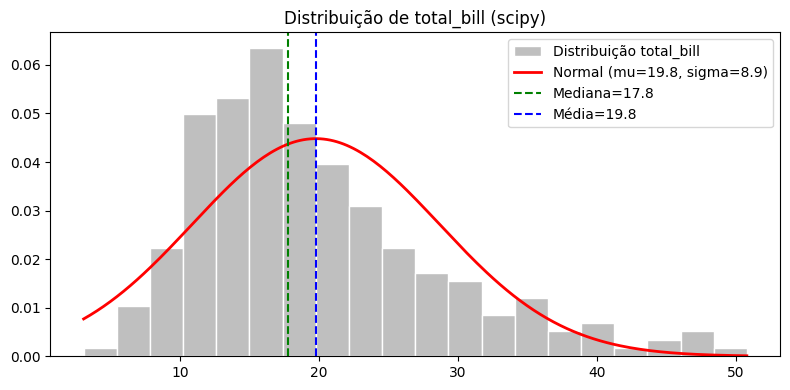

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, axes = plt.subplots(figsize=(8,4))

# histograma de total_bill vs curva normal ajustada
axes.hist(df['total_bill'], bins=20, density=True, color='0.75', edgecolor='white', label=f"Distribuição total_bill")
xs = np.linspace(df['total_bill'].min(), df['total_bill'].max(), 200)
# axes.plot(xs, norm.pdf(xs, mu, sigma), 'r-', lw=2, label=f"normal (mu={mu:.1f}, sigma={sigma:.1f})") # usando funcao do scipy
axes.plot(xs, [normal_pdf(x, mu=mu, sigma=sigma) for x in xs], 'r-', lw=2, label=f"Normal (mu={mu:.1f}, sigma={sigma:.1f})")
axes.axvline(x=mediana, color='green', linestyle='--', label=f"Mediana={mediana:.1f}")
axes.axvline(x=mu, color='blue', linestyle='--', label=f"Média={mu:.1f}")
axes.legend()
axes.set_title("Distribuição de total_bill (scipy)")

plt.tight_layout()
plt.show()

A partir do gráfico acima, podemos observar que a distribuição da variável `total_bill` possui uma cauda longa a direita, indicando que é assimétrica. Ou seja, **a variável `total_bill` não segue uma distribuição normal**.

Isso fica bem evidente porque a curva normal ajustada, que é simétrica, também foi plotada. Na verdade esse deslocamento entre a distribuição e a normal ajustada mostra o desvio entre mediana e média.

Como mencionado anteriormente, o _"tcham"_ de uma distribuição normal é que ela é completamente descrita por apenas dois números: $\mu$ e $\sigma$, o que significa que podemos calcular qualquer probabilidade sem precisar de mais nada. Para o caso de `total_bill`, por exemplo, se ela fosse normal, poderíamos calcular diretamente "qual a chance de uma conta ser maior que 40 reais" ou "entre quais valores estão 95% das contas".

Como exercício, vamos utilizar a variável `total_bill` para verificar na prática o que acontece quando assumimos como normal uma distribuição que não é normal. Vamos comparar o que a função normal prevê com o que realmente acontece nos dados:

#### 1. Estimativas de probabilidade ficam erradas por conta das caudas

Vamos calcular a previsao de "qual a chance de uma conta passar de 40 reais", usando a normal e depois calcular a probabilidade usando os dados reais.

Primeiro uso a CDF (função de distribuição cumulativa) para calcular a probabilidade de uma conta dar **até 40 reais** e então subtraio esse valor de 1, para encontrar a probabilidade da conta dar **mais de 40 reais**.

In [ ]:
# CDF da distribuicao normal para calcular a probabilidade da conta dar ate 40
prop_normal_ate_40 = normal_cdf(40, mu, sigma)
prop_normal_ate_40

0.9884152176741201

In [ ]:
# subitrai de 1 para ter a probabilidade de mais de 40
prob_normal_maior_40 = 1 - prop_normal_ate_40
print(f"{prob_normal_maior_40:.2%}")

1.16%


In [ ]:
# probabilidade real de uma conta passar de 40
prob_real_maior_40 = (len(df[df['total_bill'] > 40]['total_bill']) / len(df))
print(f"{prob_real_maior_40:.2%}")

4.10%


In [ ]:
# razao entre as probabilidades
round(prob_real_maior_40 / prob_normal_maior_40, 1)

3.5

 Usando a normal para responder a pergunta, encontramos a chance **1,16%**. Mas na realidade isso acontece **4,10%** das vezes, quase **3,5 vezes mais frequente** do que a normal prevê.

 Isso é exatamente o efeito da cauda longa à direita que identificamos visualmente: a normal "não sabe" que existem esses valores altos ocasionais, porque ela é simétrica e cai rápido demais nas pontas.

 #### 2. A regra dos 2 desvios não bate

Lembrando que a **regra empírica (68-95-99,7)** diz que:

- aproximadamente 68% dos dados ficam até 1 desvio padrão da média,
- 95% dentro de 2 desvios e
- 99,7% dentro de 3 desvios.

In [ ]:
# valor esperado, pela regra pratica da normal, para corresponder ao percentil 95%
dois_sigmas_da_media = mu + (2 * sigma)
print(f"{dois_sigmas_da_media:.2f}")

37.59


In [ ]:
# percentil real que esse valor corresponde
from scipy.stats import percentileofscore

percentil_real = percentileofscore(df['total_bill'], dois_sigmas_da_media)
print(f"{percentil_real:.2f}")

94.26


In [ ]:
# valor real que corresponde ao percentil 95%
print(f"{df['total_bill'].quantile(0.95):.2f}")

38.06


Aqui os números ficaram parecidos, mas isso é meio enganoso, porque essa métrica olha os dois lados juntos, então o excesso de valores extremos à direita meio que "se cancela" com a falta de valores extremos à esquerda na comparação agregada.

#### 3. A normal prevê algo fisicamente impossível



In [ ]:
# qual a chance de uma conta ter valor ate zero reais?
print(f"{normal_cdf(0, mu, sigma):.2%}")

1.31%


A normal atribui **1,31% de chance de uma conta ser negativa**, o que é impossível na realidade. Isso é um sintoma claro de que a normal é um modelo **aproximado e imperfeito** para essa distribuição: ela "não sabe" que os valores reais têm um limite inferior em 0.

#### Resumo

##### **Por que isso importa na prática (além de "os números batem ou não")**

Se usassemos a suposição de normalidade para descartar valores por se tratarem de outliers (uma prática comum em detecção de anomalias é considerar qualquer valor acima de 2 desvios padrão da média como outlier), estariamos **subestimando** bastante quantas contas altas são, na verdade, normais para esse restaurante, e possivelmente, sinalizando como "suspeitas" contas que são apenas parte do comportamento esperado dos clientes.

##### **Então o que ganhamos de saber que algo é normal (ou não)?**

- Se os dados **são** normais: ganhamos uma ferramenta poderosíssima que nos permite calcular qualquer probabilidade, comparar valores via z-score, aplicar testes estatísticos que assumem normalidade (muito comuns em estatística inferencial), e resumir tudo com apenas 2 números ($\mu$ e $\sigma$).
- Se os dados **não são** normais (como nas contas do restaurante): saber disso nos diz para **não confiar** em cálculos de probabilidade baseados na normal, e considerar alternativas, como transformar os dados (ex.: log de `total_bill`, que às vezes "endireita" distribuições assimétricas), usar métodos não-paramétricos (que não assumem nenhuma forma específica), ou usar a distribuição empírica real (o histograma observado) em vez da teórica.

### Teorema do Limite Central (TLC)

Em vez de olhar contas individuais, tiramos milhares de amostras aleatórias do dataset (com reposição) e calculamos a **média** de cada amostra.

In [ ]:
# media das observacoes originais
df['total_bill'].mean()

np.float64(19.78594262295082)

In [ ]:
# media de uma unica amostra de tamanho 5
df['total_bill'].sample(n=5).mean()

np.float64(21.508)

In [ ]:
# media de uma unica amostra de tamanho 30
df['total_bill'].sample(n=30).mean()

np.float64(19.641)

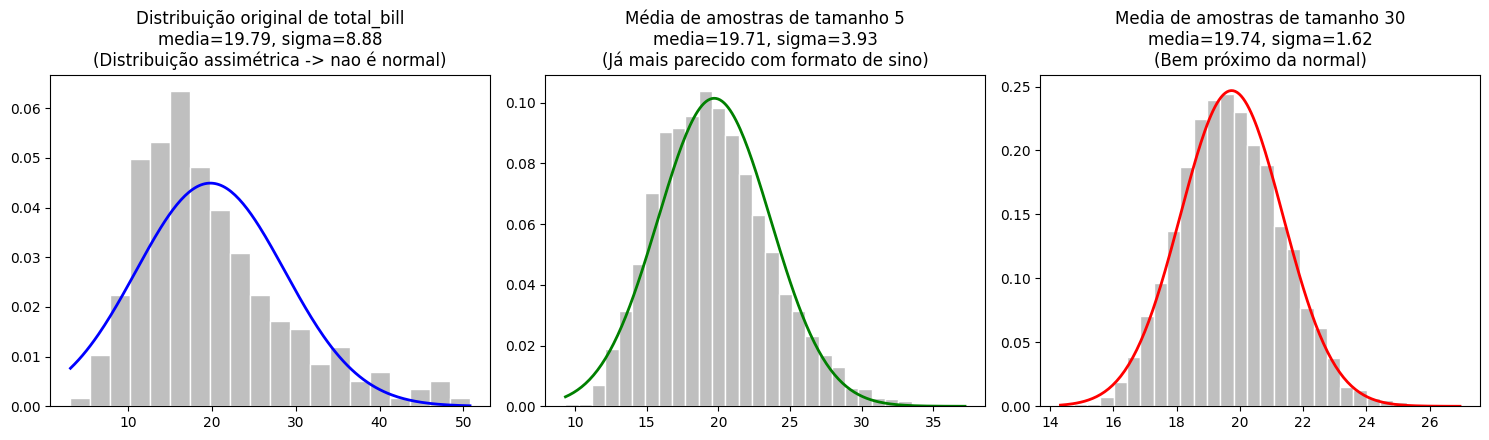

Desvio padrao original dos dados: 8.884
Desvio padrao das medias (n=5):  3.931  | previsto por TLC: sigma/sqrt(5) = 3.973
Desvio padrao das medias (n=30): 1.616  | previsto por TLC: sigma/sqrt(30) = 1.622


In [ ]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(15,4.5))

# 1) Histograma de total_bill vs curva normal ajustada
observacoes_originais = df['total_bill'].values
mu                    = observacoes_originais.mean()
sigma_original        = observacoes_originais.std()

axes[0].hist(observacoes_originais, bins=20, density=True, color='0.75', edgecolor='white')
xs = np.linspace(observacoes_originais.min(), observacoes_originais.max(), 200)
axes[0].plot(xs, norm.pdf(xs, mu, sigma_original), 'b-', lw=2)
axes[0].set_title(f"Distribuição original de total_bill\nmedia={mu:.2f}, sigma={sigma_original:.2f}\n(Distribuição assimétrica -> nao é normal)")


# 2) TLC: distribuicao das MEDIAS de amostras de tamanho 5
np.random.seed(0)
means_n5 = [np.mean(np.random.choice(df['total_bill'], size=5, replace=True)) for _ in range(5000)]
mu_5     = np.mean(means_n5)
sigma_5  = np.std(means_n5)

axes[1].hist(means_n5, bins=30, density=True, color='0.75', edgecolor='white')
xs2 = np.linspace(min(means_n5), max(means_n5), 200)
axes[1].plot(xs2, norm.pdf(xs2, mu_5, sigma_5), 'g-', lw=2)
axes[1].set_title(f"Média de amostras de tamanho 5\nmedia={mu_5:.2f}, sigma={sigma_5:.2f}\n(Já mais parecido com formato de sino)")


# 3) TLC: distribuicao das MEDIAS de amostras de tamanho 30
means_n30 = [np.mean(np.random.choice(df['total_bill'], size=30, replace=True)) for _ in range(5000)]
mu_30     = np.mean(means_n30)
sigma_30  = np.std(means_n30)

axes[2].hist(means_n30, bins=30, density=True, color='0.75', edgecolor='white')
xs3 = np.linspace(min(means_n30), max(means_n30), 200)
axes[2].plot(xs3, norm.pdf(xs3, mu_30, sigma_30), 'r-', lw=2)
axes[2].set_title(f"Media de amostras de tamanho 30\nmedia={mu_30:.2f}, sigma={sigma_30:.2f}\n(Bem próximo da normal)")

plt.tight_layout()
plt.show()

print(f'Desvio padrao original dos dados: {sigma:.3f}')
print(f'Desvio padrao das medias (n=5):  {sigma_5:.3f}  | previsto por TLC: sigma/sqrt(5) = {sigma/5**0.5:.3f}')
print(f'Desvio padrao das medias (n=30): {sigma_30:.3f}  | previsto por TLC: sigma/sqrt(30) = {sigma/30**0.5:.3f}')

Mesmo a distribuição original sendo torta, a distribuição dessas médias vai ficando cada vez mais parecida com uma normal conforme o tamanho da amostra cresce, passando de 5 para 30.

O TLC não só prevê a _forma_ normal, mas também prevê **exatamente** o desvio padrão dessas médias, pela fórmula $\sigma/\sqrt{n}$:

| n | Desvio padrão observado | Previsto pelo TLC ($\sigma/\sqrt{n}$) |
|---|---|---|
| 5 | 3,931 | 3,973 |
| 30 | 1,616 | 1,622 |

Praticamente idênticos, o que nos permite dizer que a teoria bate com a simulação.

#### **Como podemos usar o TLC nas contas de restaurante?**

O TLC não "conserta" a distribuição original de `total_bill` para permitir calcular probabilidades sobre **contas individuais**, ele permite calcular probabilidades sobre a **média de várias contas**.

**A distinção crucial**

- ❌ _"Qual a chance de **uma** conta específica ser maior que 22 reais?"_  
  Isso ainda usa a distribuição real de `total_bill` (que é assimétrica), a normal continua sendo uma má aproximação aqui.
- ✅ _"Qual a chance da **média de 30 contas** (amostradas aleatoriamente) ser maior que 22 reais?"_  
  Aqui sim o TLC entra em ação, porque estamos falando da distribuição da **média amostral**, não de uma observação isolada.

**Por que essa segunda pergunta é útil na prática**

Esse tipo de pergunta aparece o tempo todo em contextos reais: _"qual a chance da receita média por mesa hoje à noite (com 30 mesas) ficar acima de X?"_, é uma pergunta sobre um valor **agregado**, não sobre um caso individual.

Vamos calcular esse exemplo e comparar a previsão do TLC com a simulação real. Lembrando que:

- a média amostral é igual a $\mu$ ( a média das observações originais), e
- o desvio padrão é $\frac{\sigma}{\sqrt{n}}$ (onde $\sigma$ é o desvio padrão das observações originais e $n$ o tamanho das amostras)

In [ ]:
# probabilida prevista pelo TLC
prob_prevista_tlc = 1 - normal_cdf(22, mu, sigma/30**0.5)
print(f"{prob_prevista_tlc:.2%}")

8.61%


In [ ]:
# probabilida calculada na simulacao
medias_simuladas = [np.mean(np.random.choice(df['total_bill'], size=30, replace=True)) for _ in range(5000)]
prob_simulacao_30 = np.mean(np.array(medias_simuladas) > 22)
print(f"{prob_simulacao_30:.2%}")

8.98%


In [ ]:
# diferenca em pontos percentuais
print(f"{abs(prob_prevista_tlc - prob_simulacao_30):.2%}")

0.37%


In [ ]:
# probabilida calculada com parametros da distribuicao das amostras
# essa abordagem carrega um pequeno erro residual, porque o TLC eh uma APROXIMACAO da normal
prob_simulacao_30_ = 1 - normal_cdf(22, mu_30, sigma_30)
print(f"{prob_simulacao_30_:.2%}")

8.09%


Usando o TLC corretamente (perguntando sobre a média de 30 contas), encotramos:

- Previsto pelo TLC: **8,61%**
- Observado por simulação real: **9,05%**

Bem próximos! O TLC funciona bem aqui, mesmo `total_bill` sendo assimétrico, porque estamos perguntando sobre a **média de várias observações**, não sobre uma observação isolada.

E abaixo aplicamos a normal de forma **incorreta**, para uma única conta:

In [ ]:
# probabilidade de uma mesa ter conta maior que 22 reais, observando os dados reais
observacoes_dados_reais = len(df[df['total_bill'] > 22]['total_bill']) / len(df)
print(f"{observacoes_dados_reais:.2%}")

31.56%


In [ ]:
# probabilidade de uma mesa ter conta maior que 22 reais, usando funcao normal (ERRADO)
usando_funcao_normal = 1 - normal_cdf(22, mu, sigma)
print(f"{usando_funcao_normal:.2%}")

40.16%


In [ ]:
# diferenca em pontos percentuais
print(f"{abs(usando_funcao_normal - observacoes_dados_reais):.2%}")

8.60%


Aqui encontramos um erro grande, de quase 9 pontos percentuais de diferença.